In [138]:
import pandas as pd
import importlib
import sys
sys.path.append("/home/nichettg/Linux Programmi/Codici")

import funzioni as f
importlib.reload(f)
import numpy as np

import grafici as gf
importlib.reload(gf)
import matplotlib.pyplot as plt
import itertools

cmap = plt.get_cmap('Set3')
color_cycle = itertools.cycle(cmap.colors)
markers = ['o','s','^','D','v']
marker_cycle = itertools.cycle(markers)

errori = gf.default_error_params()
gf.imposta_stile_globale()

# 1 Raccolta Dati

1.1 Misurare la massa del vaso calorimetrico in rame (mr e smr) e dell'acqua (ma). Serve anche misurare quella che nelle dispense è chiamata mt? Come misuriamo la massa dell'acqua? A questo punto decidere che unità di misura usare e calcolare la capacità termica ambientale (c e sC).

1.2 Misurare la massa del blocco (mx e smx). Definire l'incertezza (sTi) della temperatura iniziale del blocchetto di 100°C. Misurare la temperatura dell'acqua subito prima di inserire il pesetto (Ta e sTa).

1.3 Misurare la temperatura dell'acqua con blocchetto immerso anche nella fase di aumento iniziale di temperatura con intervalli di 15s. Dopo passare a intervalli di 30s fino ad arrivare ad un abbassamento di almeno 0.2°C dalla temperatura massima. Ripetere per tre misure ripeture di tempi e temperature e scrivere i dati nel file dati.xlsx per poi esportarlo come dati.csv. Usare i gradi Celsius nella raccolta dati, da discutere se eventualmente usare i Kelvin nell'analisi. N.B. Non rimisurare mx e mr, ma forse rimisurare mt (cioè ma?). Questo vuol dire usare sempre la stessa massa. Serve anche definire un'incertezza st e un incertezza sT.

### 1.1 Capacità Termica Ambientale

In [139]:
# Calore specifico rame stagnato (vaso calorimetrico)
cr = 0.093 # cal/(g·°C)
scr = 0.001 # cal/(g·°C)
# Calore specifico acqua
ca = 1 # cal/(g·°C)
sa = 0 # cal/(g·°C)
# Capacità termica termometro
K = 2.20 # cal/(°C)
sK = 0.05
# Massa vaso calorimetrico
mr = 55.86 # g
smr = 0.01 / np.sqrt(12) # g
# Massa acqua
ma = (189.09 - 55.86) # g
sma = np.sqrt(smr**2 + smr**2) # g

In [140]:
def converti_unità_misura(value, conversione='calore', toSI=True):

    if conversione == 'calore':
        factor = 4186.8  # 1 cal/(g·°C) = 4186.8 J/(kg·K)
        return value * factor if toSI else value / factor

    elif conversione == 'temperatura':
        return value + 273.15 if toSI else value - 273.15
    
    elif conversione == 'massa':
        return value / 1000 if toSI else value * 1000

# Capacità termica totale dell'ambiente
def f_C(mr, scr, cr, smr, ma, sa, ca, sma, K, sK):

    C = mr * cr + ma * ca + K
    sC = np.sqrt((cr * smr)**2 + (mr * scr)**2 +
                 (ca * sma)**2 + (ma * sa)**2 + sK**2)
    return C, sC

C, sC = f_C(mr, scr, cr, smr, ma, sa, ca, sma, K, sK)

### 1.2 Altri Dati

In [141]:
# Massa blocchetto
mx = 80.81 # g
smx = 0.01 / np.sqrt(12) # g
Ti = 100.5 # °C
sTi = 0.1 / np.sqrt(12) # °C
Ta = 21.0 # °C
sTa = 0.1 / np.sqrt(24) # °C

### 1.3 Lettura "dati.csv"

In [142]:
sT = 0.1 / np.sqrt(24)
#st = 0

dati = pd.read_csv('dati.csv', sep=';')

t,T = [],[]
for i in range(1,2):
    tempo = f"tempo{i}"
    temperatura = f"temperatura{i}"
    t.append(dati[tempo].dropna().to_numpy())
    T.append(dati[temperatura].dropna().to_numpy())
del tempo, temperatura

print("t:", t)
print("T:", T)

t: [array([  0,  15,  30,  45,  60,  75,  90, 105, 120, 135, 150, 165, 180,
       195, 210, 225, 240, 255, 270, 285, 300, 315, 330, 345, 360, 375,
       390, 405, 420, 435, 450, 465, 480, 495, 510, 525, 540, 555, 570,
       585, 600, 615, 630, 645, 660, 675, 690, 705, 720, 735, 750, 765,
       780, 795, 810, 825, 840, 855, 870, 885, 900, 915, 930, 945])]
T: [array([21. , 21.3, 21.9, 25.7, 26. , 26. , 26. , 26. , 26. , 26. , 26. ,
       26. , 26. , 26. , 26. , 26. , 26. , 26. , 26. , 26. , 25.9, 25.9,
       25.9, 25.9, 25.9, 25.9, 25.9, 25.9, 25.9, 25.9, 25.9, 25.9, 25.9,
       25.9, 25.9, 25.9, 25.9, 25.9, 25.8, 25.8, 25.8, 25.8, 25.8, 25.8,
       25.8, 25.8, 25.8, 25.8, 25.8, 25.8, 25.8, 25.8, 25.8, 25.8, 25.8,
       25.8, 25.8, 25.8, 25.8, 25.8, 25.8, 25.8, 25.8, 25.8])]


# 2 Analisi

### 2.1 Interpolazione

In [143]:
parametri = []
for i in range(len(t)):
    output_name = f"./Elaborati/elaborato{i+1}.txt"
    f.output_init(output_name)
    indice_inizio = np.argmax(T[i])
    parametri.append(np.array(f.elaborato(t[i][indice_inizio:],T[i][indice_inizio:],sT,output_name,i,ritorno=True)))
parametri = np.array(parametri)
print(parametri)

Minimi quadrati I
Processo al calcolatore

[[ 2.60311466e+01 -2.94155784e-04  5.73843740e-03  1.01444178e-05]]


### 2.2 Grafico

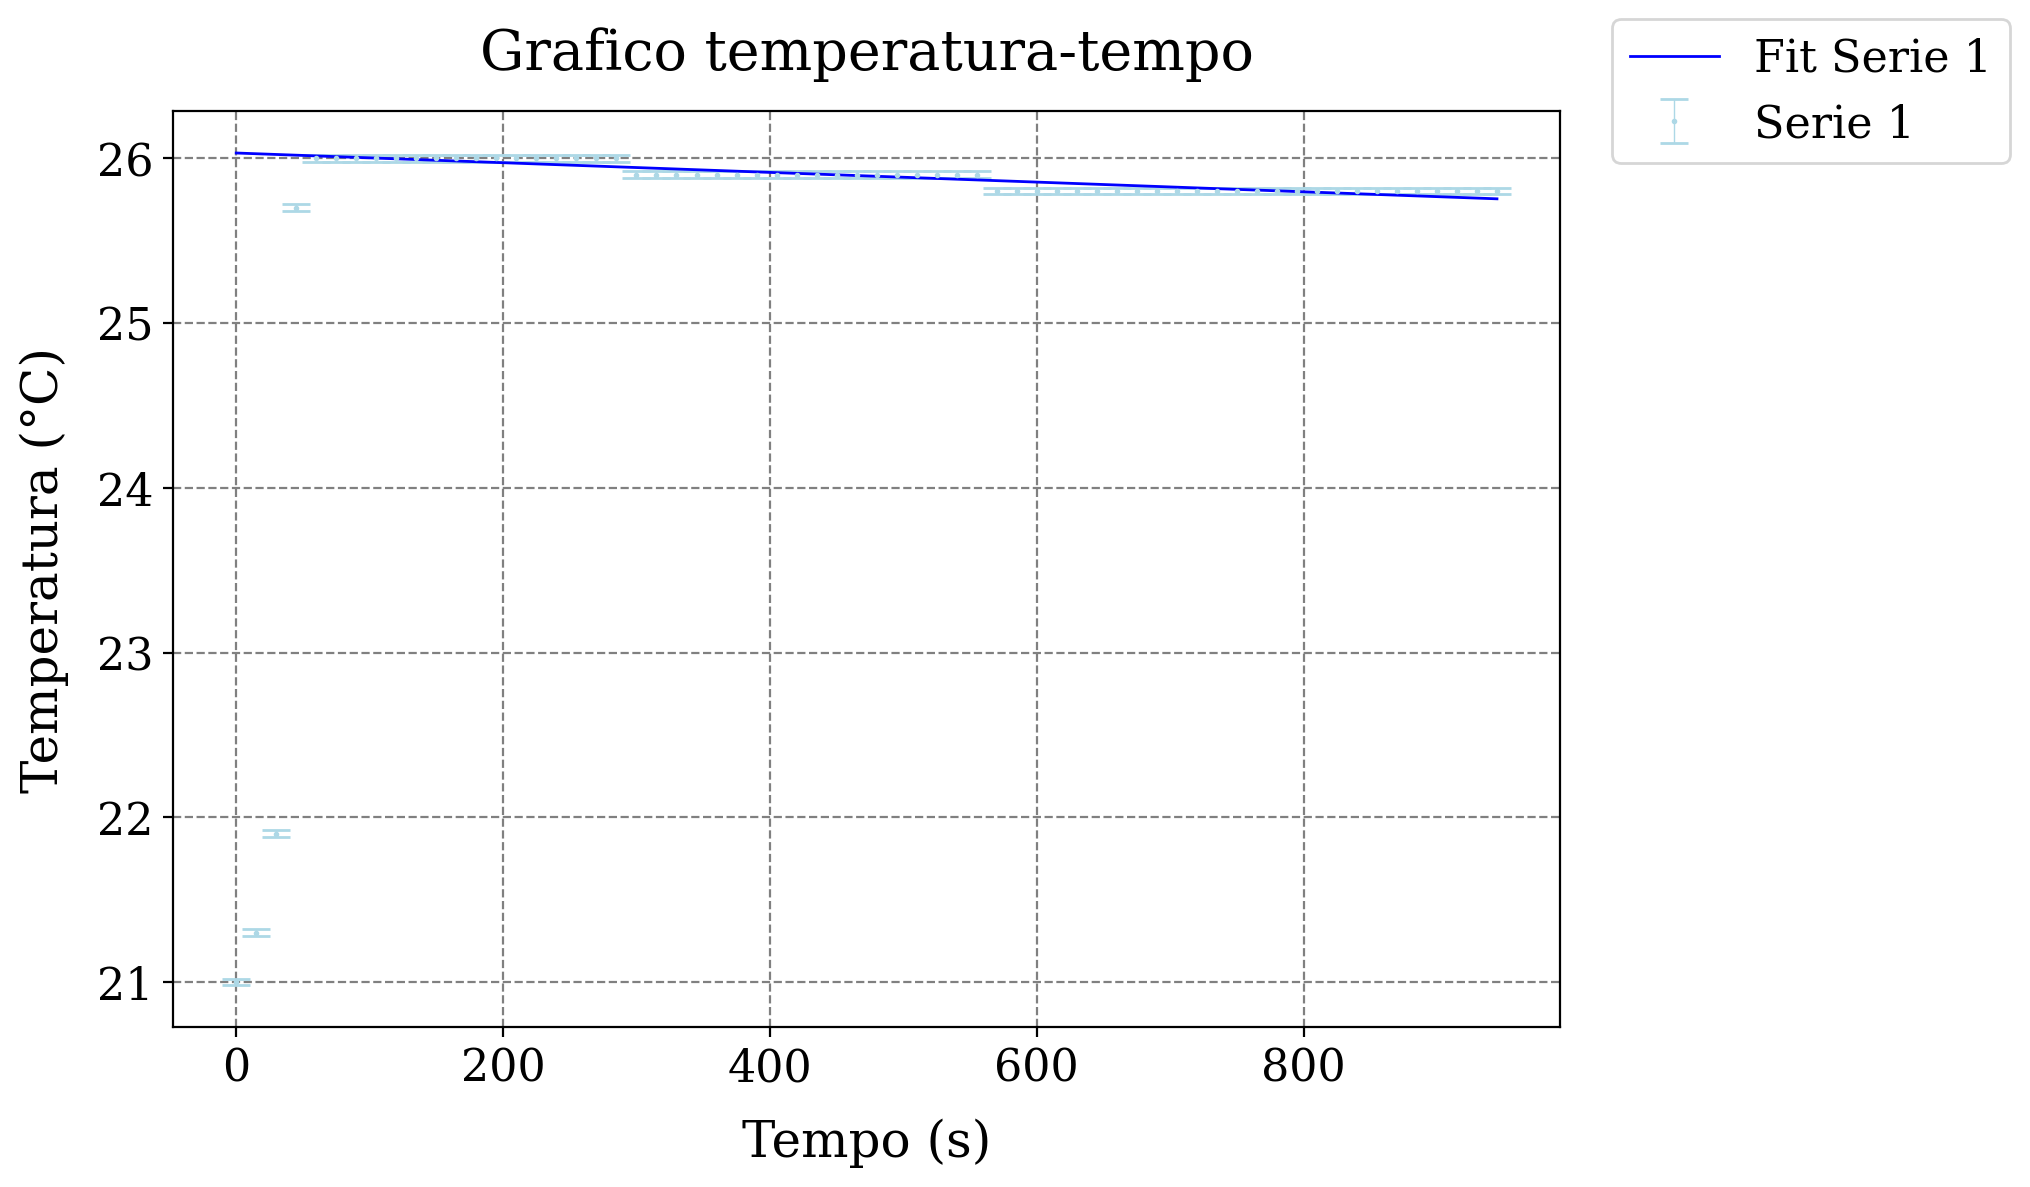

In [144]:
fig, ax = plt.subplots()

for i in range(len(t)):
# Scatter
    #color = next(color_cycle)
    label = f"Serie {i+1}"
    #marker = next(marker_cycle)
    ax.errorbar(t[i], T[i], yerr=sT, fmt=".", color="lightblue", markersize = 2, label = label, **errori)

# Fit
    a, b, sa, sb = parametri[i]
    x_values = np.linspace(0, max(t[i]), 100)
    y_values = a + b * x_values
    ax.plot(x_values, y_values, color="blue", linestyle='-', linewidth = 1, label=f"Fit {label}")
del a,b,sa,sb

gf.parametri_grafico(ax, titolo = "Grafico temperatura-tempo", xlabel = "Tempo (s)", ylabel = "Temperatura (°C)")
gf.salva_grafico(fig, f"./Images/grafico.pdf")

# 3 Stima Calore Specifico

3.1 Per stimare la temperatura d'equilibrio (Teq) un opzione ragionevole è quella di considerare la media delle temperature di equilibrio ipotizzando il campione gaussiano (si vedrà poi che questa ipotesi è errata). Quindi si calcola la media delle temperature a partire dal picco e si considera come incertezza la deviazione standard della media.

3.2 Sulla base dei dati si stima il calore specifico del blocchetto (Cx e sCx).

### 3.1 Stima Temperatura Equilibrio

In [145]:
equilibri=[]
sequilibri=[]
for serie in T:
    equilibri.append(f.media(serie[np.argmax(serie):])) # Viene fatta la media dei valori che seguono il massimo
    sequilibri.append(f.dev(serie[np.argmax(serie):]) / np.sqrt(len(serie[np.argmax(serie):]) - 1)) # Deviazione standard media

Teq = f.media(equilibri) # °C
sTeq = sequilibri[0] # °C

print(f"{Teq}\n{sTeq}")

25.883333333333308
0.010764157561162457


### 3.2 Calcolo Calore Specifico

In [146]:
def f_Cx(C, sC, Teq, sTeq, Ta, sTa, mx, smx, Ti, sTi):
    num = C * (Teq - Ta)
    den = mx * (Ti - Teq)
    Cx = num / den

    # Derivate parziali
    dC = (Teq - Ta) / den
    dTeq = C * (Ti - Ta) / (mx * (Ti - Teq)**2)
    dTa = -C / den
    dmx = -C * (Teq - Ta) / (mx**2 * (Ti - Teq))
    dTi = -C * (Teq - Ta) / (mx * (Ti - Teq)**2)

    # Propagazione dell'incertezza
    sCx = np.sqrt((dC * sC)**2 + (dTeq * sTeq)**2 + (dTa * sTa)**2 +
                  (dmx * smx)**2 + (dTi * sTi)**2)

    return Cx, sCx

Cx,sCx = f_Cx(C, sC, Teq, sTeq, Ta, sTa, mx, smx, Ti, sTi)

# 4 Sistematiche

4.1 Verificare la decrescenza del fit lineare e verificare la compatibilità tra le (prime) misure. Ci si aspetta un andamento decrescente secondo la legge 
$$T = Teq - a t$$
dovuto alla perdita lineare di calore per un non perfetto isolamento termico. Per stimare la temperatura d'equilibrio (Teq) un opzione ragionevole è quella di considerare il picco della temperatura. Per la sua incertezza si potrebbe usare la deviazione standard campionaria della media dei tre picchi delle tre serie. Si potrebbe altrimenti definire come temperatura di equilibrio il valore dell'intercetta (proposto da Mengoni nelle dispense). Si potrebbe anche provare, secondo la formula sopracitata, ad eseguire una correzione sui dati per renderli gaussiani. Da definire altri eventuali metodi. 

4.2 Tenere in considerazione un eventuale abbassamento di temperatura nel passaggio della massa dall'agitatore all'acqua. Teoricamente l'abbassamento è di $$ 1.5 \pm 0.7 °C$$.

4.3 Nuovo calcolo del calore specifico con confronto tra i vari valori.

### 4.1 Effetto Isolamento Termico

In [147]:
massimo=[]
for serie in T:
    massimo.append(np.max(serie))

Teq_corr = f.media(massimo)
sTeq_corr = (f.dev(massimo)) / np.sqrt(len(massimo))

/home/nichettg/Linux Programmi/Codici/funzioni.py:24: RuntimeWarning: invalid value encountered in scalar divide
  return math.sqrt(sum((x - m) ** 2 for x in v) / (len(v) - 1))


### 4.2 Effetto Ambientale sul Blocco

In [148]:
T_corr = 1.5 # °c
sT_corr = 0.7 # °C
Ti_corr = Ti + T_corr
sTi_corr = np.sqrt(sTi**2 + sT_corr**2)

### 4.3 Calcolo Calore Specifico

In [149]:
import tabulate

Cx_corr1, sCx_corr1 = f_Cx(C, sC, Teq_corr, sTeq_corr, Ta, sTa, mx, smx, Ti, sTi)
Cx_corr2, sCx_corr2 = f_Cx(C, sC, Teq, sTeq, Ta, sTa, mx, smx, Ti_corr, sTi_corr)
Cx_corr, sCx_corr = f_Cx(C, sC, Teq_corr, sTeq_corr, Ta, sTa, mx, smx, Ti_corr, sTi_corr)

print("Confronto tra i calori specifici calcolati:\n")
rows = [
    ["Originale",     Cx,       sCx],
    ["Correzione Teq", Cx_corr1, sCx_corr1],
    ["Correzione Ti",  Cx_corr2, sCx_corr2],
    ["Entrambe Correzioni", Cx_corr, sCx_corr],
]

headers = ["Caso", "Cx (cal/g°C)", "Incertezza"]

print(tabulate.tabulate(rows, headers=headers, floatfmt=".4f"))

Confronto tra i calori specifici calcolati:

Caso                   Cx (cal/g°C)    Incertezza
-------------------  --------------  ------------
Originale                    0.1139        0.0006
Correzione Teq               0.1168      nan
Correzione Ti                0.1116        0.0012
Entrambe Correzioni          0.1145      nan
